In [1]:
import mne
import numpy as np
import pandas as pd
import os

In [2]:
def preprocess_eeg(file_path):
    raw = mne.io.read_raw_edf(file_path, preload=True)
    
    # 🔥 Rename channels to 10-20 format
    mapping = {}
    for ch in raw.ch_names:
        new_name = ch.replace('EEG ', '').replace('-CPz', '').strip()
        mapping[ch] = new_name
    
    raw.rename_channels(mapping)
    
    # Keep only EEG
    raw.pick_types(eeg=True)
    
    # Apply 10-20 montage
    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage, on_missing='ignore')
    
    # Filtering
    raw.filter(0.1, 30)
    raw.notch_filter(50)
    
    # Referencing
    raw.set_eeg_reference('average')
    
    return raw

In [3]:
def get_epochs(raw):
    events, event_id = mne.events_from_annotations(raw)
    
    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_id,
        tmin=-0.2,
        tmax=0.8,
        baseline=(None, 0),
        preload=True,
        event_repeated='merge'
    )
    
    return epochs

In [4]:
def extract_features(epochs):
    sfreq = epochs.info['sfreq']
    
    important_channels = ['Pz', 'Cz', 'P3', 'P4']  # 🔥 P300 relevant
    
    features = []
    
    for trial in epochs.get_data():
        
        row = []
        
        for ch in important_channels:
            if ch in epochs.ch_names:
                idx = epochs.ch_names.index(ch)
                signal = trial[idx]
                
                amp = np.max(signal)
                lat = np.argmax(signal) / sfreq
                
                row.extend([amp, lat])
            else:
                row.extend([0, 0])
        
        features.append(row)
    
    return np.array(features), important_channels

In [5]:
def process_folder(folder_path, label):
    X_all = []
    y_all = []
    
    for file in os.listdir(folder_path):
        if file.endswith(".edf"):
            path = os.path.join(folder_path, file)
            print("Processing:", file)
            
            try:
                raw = preprocess_eeg(path)
                epochs = get_epochs(raw)
                
                # Select target event
                target_key = [k for k in epochs.event_id.keys() if "target" in k.lower()][0]
                
                X, channels = extract_features(epochs[target_key])
                
                X_all.extend(X)
                y_all.extend([label]*len(X))
            
            except Exception as e:
                print("Error:", file, e)
    
    return np.array(X_all), np.array(y_all), channels

In [6]:
folder = r"E:\aditi_eeg\visual_eeg\tbi"

X, y, channels = process_folder(folder, label=1)

Processing: p1_a_2026-04-06_11-01-25_Segment_0.edf
Extracting EDF parameters from E:\aditi_eeg\visual_eeg\tbi\p1_a_2026-04-06_11-01-25_Segment_0.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 111499  =      0.000 ...   222.998 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 16501 samples (33.002 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop fi

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Condition Baseline End  EpochE', 'Condition Baseline Start  EpochE', 'Condition Task_End  EpochE', 'Condition Task_Start  EpochE', 'Condition non target  EpochE', 'Condition target  EpochE', 'EventCode 1002  EpochE', 'EventCode 1003  EpochE', 'EventCode 1004  EpochE', 'EventCode 1005  EpochE', 'EventCode 1006  EpochE', 'EventCode 1007  EpochE', 'Impedance']
Multiple event values for single event times found. Creating new event value to reflect simultaneous events.
Not setting metadata
87 matching events found
Setting baseline interval to [-0.2, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 87 events and 501 original time points ...
2 bad epochs dropped
Processing: p1_a_2026-04-06_11-17-23_Segment_0.edf
Extracting EDF parameters from E:\aditi_eeg\visual_eeg\tbi\p1_a_2026-04-06_11-

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6759 samples (6.601 s)

EEG channel type selected for re-referencing


...

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Condition Baseline End  EpochE', 'Condition Baseline Start  EpochE', 'Condition Task_End  EpochE', 'Condition Task_Start  EpochE', 'Condition non target  EpochE', 'Condition target  EpochE', 'EventCode 1002  EpochE', 'EventCode 1003  EpochE', 'EventCode 1004  EpochE', 'EventCode 1005  EpochE', 'EventCode 1006  EpochE', 'EventCode 1007  EpochE', 'Impedance']
Multiple event values for single event times found. Creating new event value to reflect simultaneous events.
Not setting metadata
69 matching events found
Setting baseline interval to [-0.2001953125, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 69 events and 1025 original time points ...
2 bad epochs dropped
Processing: p7_visual_2026-04-06_12-59-46_Segment_0.edf
Extracting EDF parameters from E:\aditi_eeg\visual_eeg\tbi\p7_v

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6759 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Condition Baseline End  EpochE', 'Condition Baseline Start  EpochE', 'Condition Task_End  EpochE', 'Condition Task_Start  EpochE', 'Condition non target  EpochE', 'Condition target  EpochE', 'EventCode 1002  EpochE', 'EventCode 1003  EpochE', 'EventCode 1004  EpochE', 'EventCode 1005  EpochE', 'EventCode 1006  EpochE', 'EventCode 1007  EpochE', 'Impedance']
Multiple event values for single event times found. Creating new event value to reflect simultaneous events.
Not setting metadata
85 matching events found
Setting baseline interval to [-0.2001953125, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 85 events and 1025 original time points ...
1 bad epochs dropped


In [7]:
print("Channels used:", channels)

Channels used: ['Pz', 'Cz', 'P3', 'P4']


In [8]:
columns = []
for ch in channels:
    columns.extend([f"{ch}_amp", f"{ch}_lat"])

In [9]:
import pandas as pd
import os

df = pd.DataFrame(X, columns=columns)
df["Label"] = y

In [10]:
save_path = r"E:\aditi_eeg\visual_eeg"
os.makedirs(save_path, exist_ok=True)

In [11]:
df.to_excel(os.path.join(save_path, "dataset.xlsx"), index=False)

In [12]:
df.to_csv(os.path.join(save_path, "dataset.csv"), index=False)

In [13]:
import numpy as np

np.save(os.path.join(save_path, "X.npy"), X)
np.save(os.path.join(save_path, "y.npy"), y)

In [15]:
print(df.columns)

Index(['Pz_amp', 'Pz_lat', 'Cz_amp', 'Cz_lat', 'P3_amp', 'P3_lat', 'P4_amp',
       'P4_lat', 'Label'],
      dtype='object')


In [16]:
df['Avg_Amplitude'] = df[['Pz_amp','Cz_amp','P3_amp','P4_amp']].mean(axis=1)
print(df['Avg_Amplitude'])

0      0.000018
1      0.000014
2      0.000023
3      0.000015
4      0.000028
         ...   
326    0.000022
327    0.000024
328    0.000056
329    0.000051
330    0.000071
Name: Avg_Amplitude, Length: 331, dtype: float64


In [17]:
df['Avg_Latency'] = df[['Pz_lat','Cz_lat','P3_lat','P4_lat']].mean(axis=1)
print(df['Avg_Latency'])

0      0.838500
1      0.230500
2      0.952000
3      0.170500
4      0.906000
         ...   
326    0.153320
327    0.657227
328    0.592285
329    0.424072
330    0.598877
Name: Avg_Latency, Length: 331, dtype: float64


In [18]:
p300_amp = df['Pz_amp']
p300_lat = df['Pz_lat']

print("P300 Amplitude:\n", p300_amp)
print("P300 Latency:\n", p300_lat)

P300 Amplitude:
 0      0.000020
1      0.000014
2      0.000022
3      0.000016
4      0.000023
         ...   
326    0.000023
327    0.000026
328    0.000054
329    0.000049
330    0.000068
Name: Pz_amp, Length: 331, dtype: float64
P300 Latency:
 0      0.978000
1      0.300000
2      0.942000
3      0.220000
4      0.916000
         ...   
326    0.153320
327    0.806641
328    0.582031
329    0.421875
330    0.598633
Name: Pz_lat, Length: 331, dtype: float64


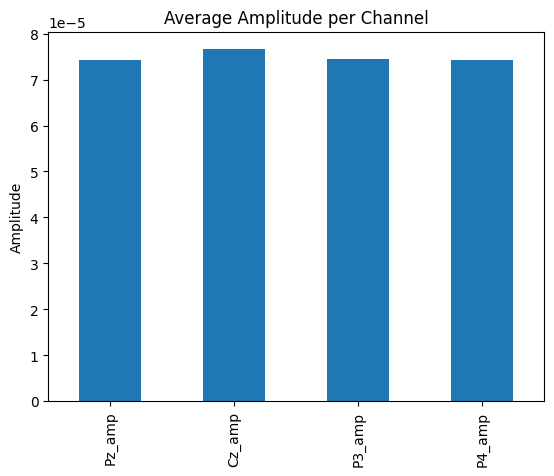

In [19]:
import matplotlib.pyplot as plt

df[['Pz_amp','Cz_amp','P3_amp','P4_amp']].mean().plot(kind='bar')
plt.title("Average Amplitude per Channel")
plt.ylabel("Amplitude")
plt.show()

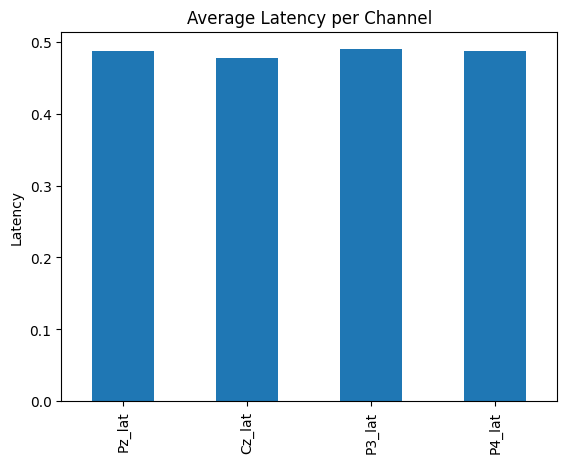

In [20]:
df[['Pz_lat','Cz_lat','P3_lat','P4_lat']].mean().plot(kind='bar')
plt.title("Average Latency per Channel")
plt.ylabel("Latency")
plt.show()

In [21]:
import numpy as np

X = np.load('X.npy')
Y = np.load('Y.npy')

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (331, 8)
Y shape: (331,)


In [23]:
import numpy as np

X = np.load('X.npy')
Y = np.load('Y.npy')

# P300 from Pz channel
p300_amp = X[:, 0]   # Pz_amp
p300_lat = X[:, 1]   # Pz_lat

print("P300 Amplitude:\n", p300_amp)
print("P300 Latency:\n", p300_lat)

P300 Amplitude:
 [1.98059269e-05 1.39545039e-05 2.22067467e-05 1.60735303e-05
 2.32771802e-05 2.23122200e-05 3.86826081e-05 2.08332957e-05
 1.68859245e-05 3.00435160e-05 1.31317780e-05 2.12975860e-05
 1.27249727e-05 1.20352925e-05 2.59603233e-05 1.68877271e-05
 1.12154795e-05 1.38197853e-05 3.21330650e-05 1.39118512e-05
 2.46925919e-05 1.32206985e-05 2.41369656e-05 2.11902858e-05
 2.97176491e-05 1.83303503e-05 1.65637181e-05 1.98159375e-05
 1.52771256e-05 1.54171792e-05 3.97445573e-05 1.97348543e-05
 8.66671699e-04 4.51687949e-05 2.16459625e-04 1.42114486e-04
 2.19745649e-05 1.91725642e-05 3.32342518e-05 1.07083758e-05
 1.19043420e-05 6.71613417e-06 8.23480515e-05 9.07307237e-05
 2.11307367e-05 7.81456393e-05 2.84386016e-05 8.50654498e-05
 6.84666121e-05 1.26244633e-05 1.96245259e-04 1.69443605e-05
 3.09554733e-05 2.55616153e-05 3.99357355e-05 3.23823671e-05
 9.12061491e-06 3.55213119e-05 1.70974964e-05 1.57328081e-05
 2.66031412e-05 2.66484897e-05 2.45237547e-05 2.19217062e-05
 2.3541

In [24]:
target_amp = p300_amp[Y == 1]
nontarget_amp = p300_amp[Y == 0]

print("Target P300 Amplitude Mean:", np.mean(target_amp))
print("Non-Target Amplitude Mean:", np.mean(nontarget_amp))

Target P300 Amplitude Mean: 7.432450737547044e-05
Non-Target Amplitude Mean: nan


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


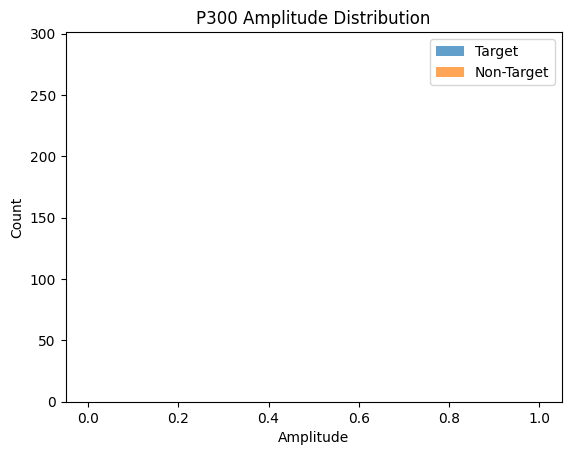

In [25]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(target_amp, alpha=0.7, label="Target")
plt.hist(nontarget_amp, alpha=0.7, label="Non-Target")
plt.legend()
plt.title("P300 Amplitude Distribution")
plt.xlabel("Amplitude")
plt.ylabel("Count")
plt.show()